#TASK 1: Advanced objective Function and Use Case

## TASK 1 QUESTION 1
### Derive the objective function for Logistic Regression using Maximum Likelihood

logistic regression models the probability of the positive class as
\begin{equation}
p_i \;\equiv\; P\!\left(y_i = 1 \mid x_i; w,b\right)
\;=\; \sigma(z_i)
\;=\; \frac{1}{1 + e^{-z_i}},
\qquad
z_i \;=\; w^\top x_i + b.
\end{equation}


Given a dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$,
 the likelihood function is the product of probabilities for each observed label:
$
L(\theta) = \prod_{i=1}^n P(y_i = 1 \mid \mathbf{x}_i; \theta)^{y_i} \bigl[1 - P(y_i = 1 \mid \mathbf{x}_i; \theta)\bigr]^{(1 - y_i)}.$

Since $P(y_i = 1 \mid \mathbf{x}_i; \theta) = \sigma(z_i)$, we can rewrite this as:
$L(\theta) = \prod_{i=1}^n \sigma(z_i)^{y_i} \,[1 - \sigma(z_i)]^{(1-y_i)}.$

Then, $
\ell(\theta) = \log L(\theta) = \sum_{i=1}^n \Bigl[y_i \log(\sigma(z_i)) + (1 - y_i) \log\bigl(1 - \sigma(z_i)\bigr)\Bigr].


 Turn into likelihood of a sum by taking logs
$
\ell(\theta) = \log L(\theta) = \sum_{i=1}^n \Bigl[y_i \log(\sigma(z_i)) + (1 - y_i) \log\bigl(1 - \sigma(z_i)\bigr)\Bigr].
$

$
J(\theta) \;=\; -\ell(\theta)
\;=\; \sum_{i=1}^n \Big[ -y_i \log \sigma(z_i) - (1-y_i)\log(1-\sigma(z_i)) \Big].
$

### Map Technique for Logistic Regression

MAP includes prior knowledge. MAP is like the same as MLE except for the prior $P(\theta)$.
Hence, the MAP objective often looks like:
$
J_{\text{MAP}}(\theta) = -\sum_{i=1}^n \Bigl[y_i \log(\sigma(z_i)) + (1 - y_i)\log(1-\sigma(z_i))\Bigr] - \log P(\theta).
$

### MLE VS MAP
Key differences between MLE and MAP:
- MLE can overfit when $n$ is small or if there are a lot of features
- MAP provides regularization and does not incorporate prior information about $\theta$

MLE : $\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} P(X,y \mid \theta)$.

MAP : $\hat{\theta}_{\text{MAP}} = \arg\max_{\theta} [P(X,y \mid \theta)\,P(\theta)]$.

## REFERENCES
https://sassafras13.github.io/MLEvsMAP/


## TASK 1 QUESTION 2

I aim to develop a predictive model that classifies whether a student is going to pass or fail an exam based on characteristics that can impact a students score. These characteristics include how much time they spent on the exam studying, if they received tutoring, any extracurriculars, etc. Using logistic regression is the best choice for binary outcomes. The model also provides insights how much each feature impacts the probabilty of the student passing the course. Moreso, given the size of the dataset, logistic regression offers a mix between performance and computational efficency.

Comparing this model to the linear discriminant analysis (LDA), logistic regression usually works better when the data is "messy", whereas LDA works best when the amount of data per class is more similar.

###References https://papers.nips.cc/paper_files/paper/2001/hash/7b7a53e239400a13bd6be6c91c4f6c4e-Abstract.html

## Task 1 - Question 3 : Discuss how your dataset corresponds to the variables in your equations, highlighting any assumptions in your derivation from part 1.

Features (X).
The dataset includes 20 features for each one student Each column is a measurable factor about that student. These columns form the input matrix X. For each single student i, their feature vector is $x_i$. In the above equation, $z_i$ is a weighted student performance score.

Target variable (y).
The outcome variable is a binary label. $y_i$ is equal to 1 if the students outcome is successful. The label is equal to 0 if the student was not successful, aka, they did not pass the exam.

The sigmoid transformation turns the score $z_i$ into a probability. $P_I$ is the probability the student will be successful for scoring over a 70.

### Assumptions in Derivation

I assume each student record is independent. This is a reasonable assumption if no same student appears multiple times.

I assume no feature is an exact linear comboniation of others, and if so, we will use VIF to handle it.

# TASK 2 DATASET AND ADVANCED DATASET

Data Set Chosen : Student Academic Performance
https://www.kaggle.com/datasets/ayeshasiddiqa123/student-perfirmance/data

## Task 2 question 2  Perform Exploratory Data Analysis (EDA), addressing potential multicollinearity among features. Use Variance Inflation Factor (VIF) to identify highly correlated variables and demonstrate steps to handle them.

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasiddiqa123/student-perfirmance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-perfirmance' dataset.
Path to dataset files: /kaggle/input/student-perfirmance


In [ ]:
print(f"Files in {path}:")
files = os.listdir(path)
print(files)
csv_files = [f for f in files if f.endswith('.csv')]

if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)

    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    print("\nDataset Info:")
    df.info()

    print("\nSummary Statistics:")
    display(df.describe())
else:
    print("No CSV file found in the directory.")



Files in /kaggle/input/student-perfirmance:
['StudentPerformanceFactors.csv']

First 5 rows of the dataset:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Distribution of 'Pass_Exam':


,count
Pass_Exam,
1,4476
0,2131


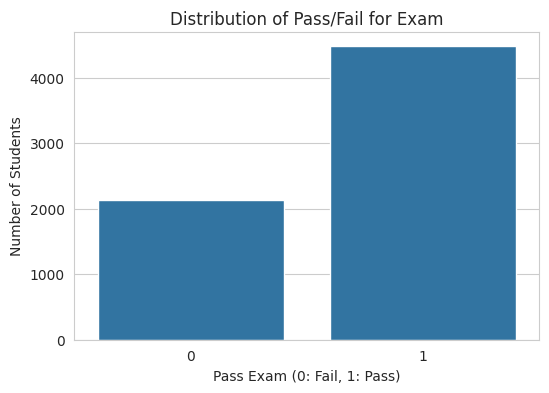

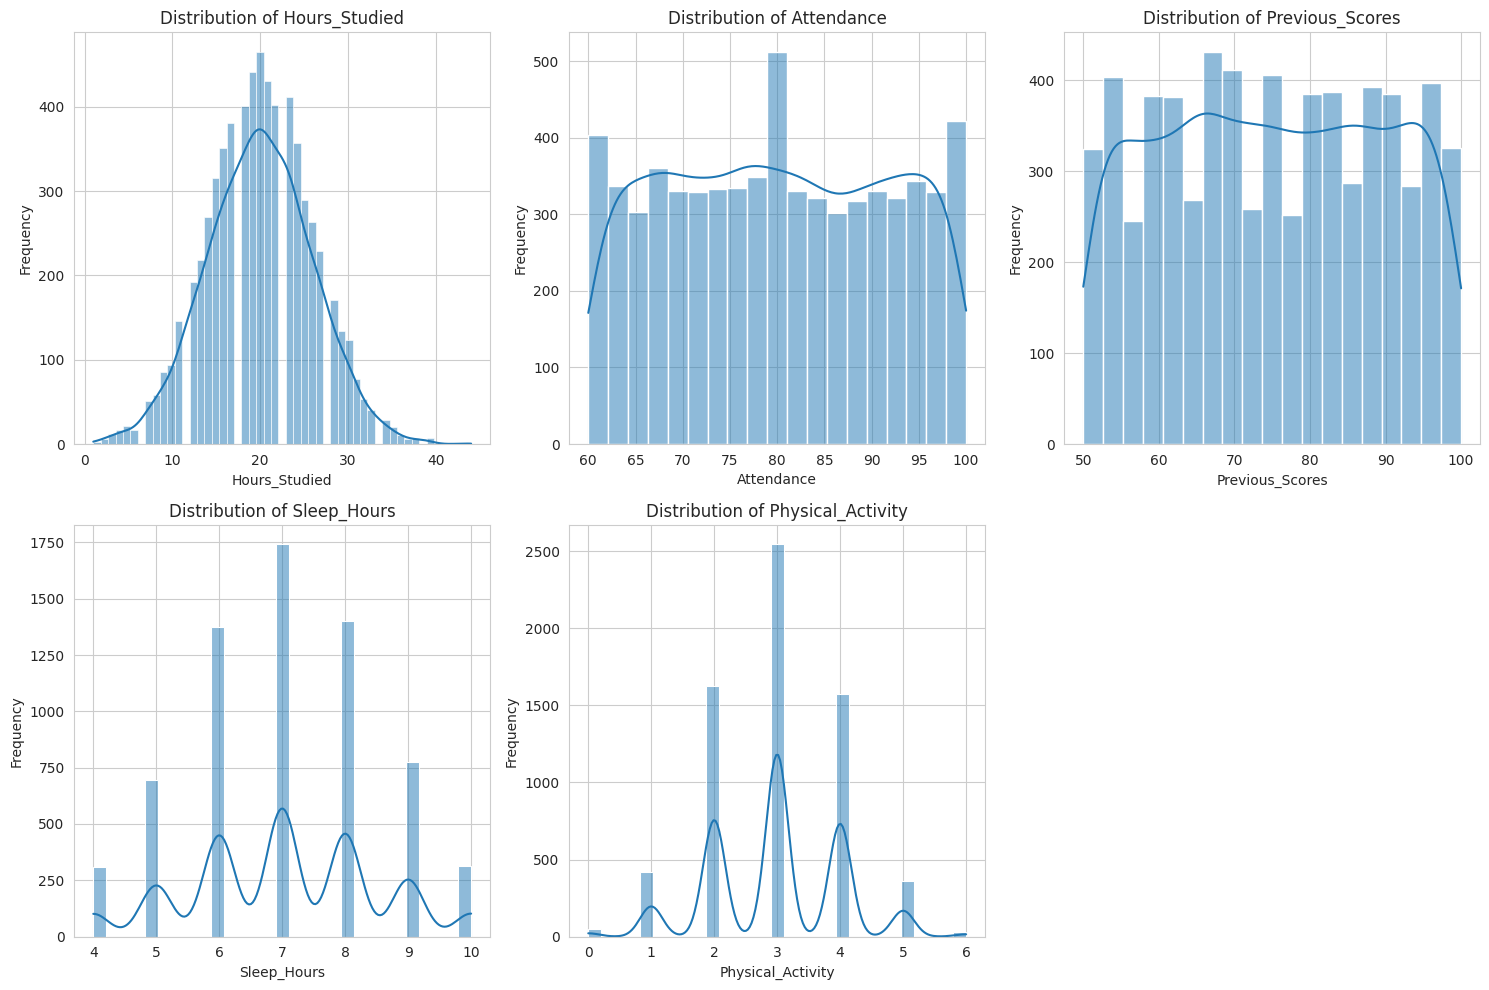

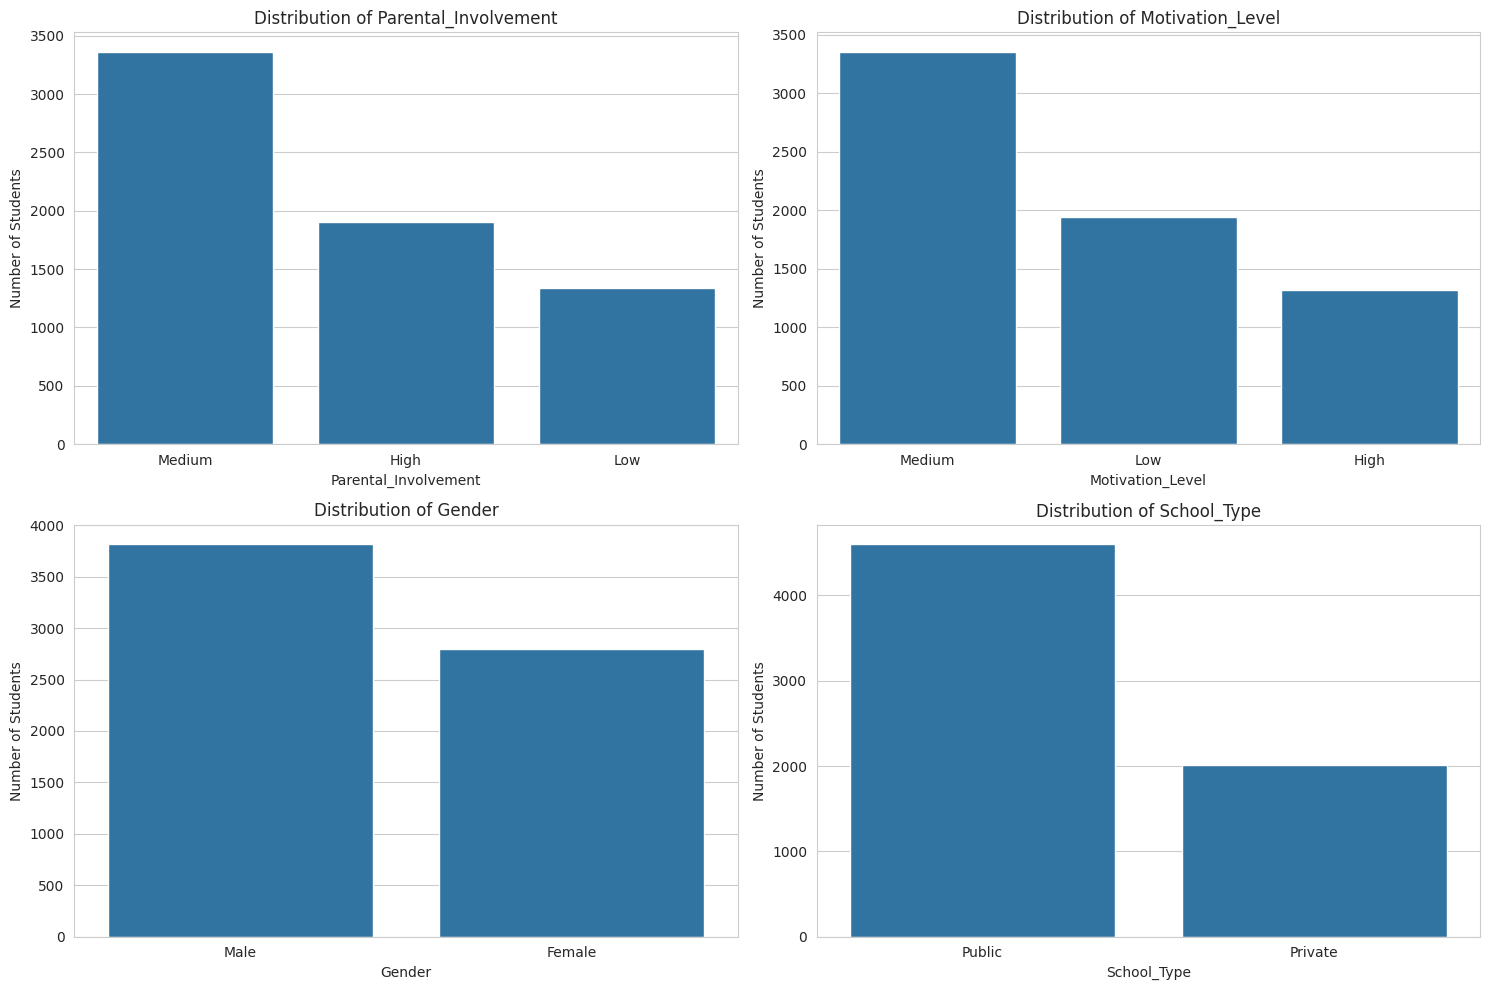

In [ ]:
import numpy as np

df['Pass_Exam'] = (df['Exam_Score'] > 65).astype(int)

print("Distribution of 'Pass_Exam':")
display(df['Pass_Exam'].value_counts())

sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='Pass_Exam', data=df)
plt.title('Distribution of Pass/Fail for Exam')
plt.xlabel('Pass Exam (0: Fail, 1: Pass)')
plt.ylabel('Number of Students')
plt.show()

numerical_features = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Sleep_Hours', 'Physical_Activity']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

categorical_features = ['Parental_Involvement', 'Motivation_Level', 'Gender', 'School_Type']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, data=df, order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

target = "Exam_Score"

X = df.drop(columns=[target])
X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors="coerce").astype(float)
X = X.fillna(X.median(numeric_only=True))

def compute_vif_table(X_df: pd.DataFrame) -> pd.DataFrame:
    """Return VIF table (excluding intercept) for a numeric feature matrix."""
    X_const = add_constant(X_df, has_constant="add")
    vif_df = pd.DataFrame({
        "feature": X_const.columns,
        "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    }).sort_values("VIF", ascending=False)
    return vif_df[vif_df["feature"] != "const"].reset_index(drop=True)

VIF_THRESHOLD = 10.0
removed_features = []
max_iters = 100

for _ in range(max_iters):
    vif_table = compute_vif_table(X)
    max_vif = float(vif_table["VIF"].iloc[0])
    if max_vif <= VIF_THRESHOLD:
        break

    worst_feature = vif_table["feature"].iloc[0]
    removed_features.append((worst_feature, max_vif))
    X = X.drop(columns=[worst_feature])

print(f"Removed {len(removed_features)} features with VIF > {VIF_THRESHOLD}:")
for feat, v in removed_features:
    print(f"  - {feat} (VIF={v:.2f})")

final_vif = compute_vif_table(X)
display(final_vif.head(20))
print(f"Remaining features: {X.shape[1]}")
print(f"Final max VIF: {final_vif['VIF'].max():.2f}")


Removed 0 features with VIF > 10.0:


,feature,VIF
0,Distance_from_Home_Near,2.651868
1,Distance_from_Home_Moderate,2.632124
2,Pass_Exam,2.421930
3,Family_Income_Low,1.885757
4,Family_Income_Medium,1.863864
5,Peer_Influence_Positive,1.792262
6,Motivation_Level_Low,1.783933
7,Peer_Influence_Neutral,1.764799
8,Attendance,1.760442
9,Motivation_Level_Medium,1.759318


Remaining features: 28
Final max VIF: 2.65


## Question 2 part 2

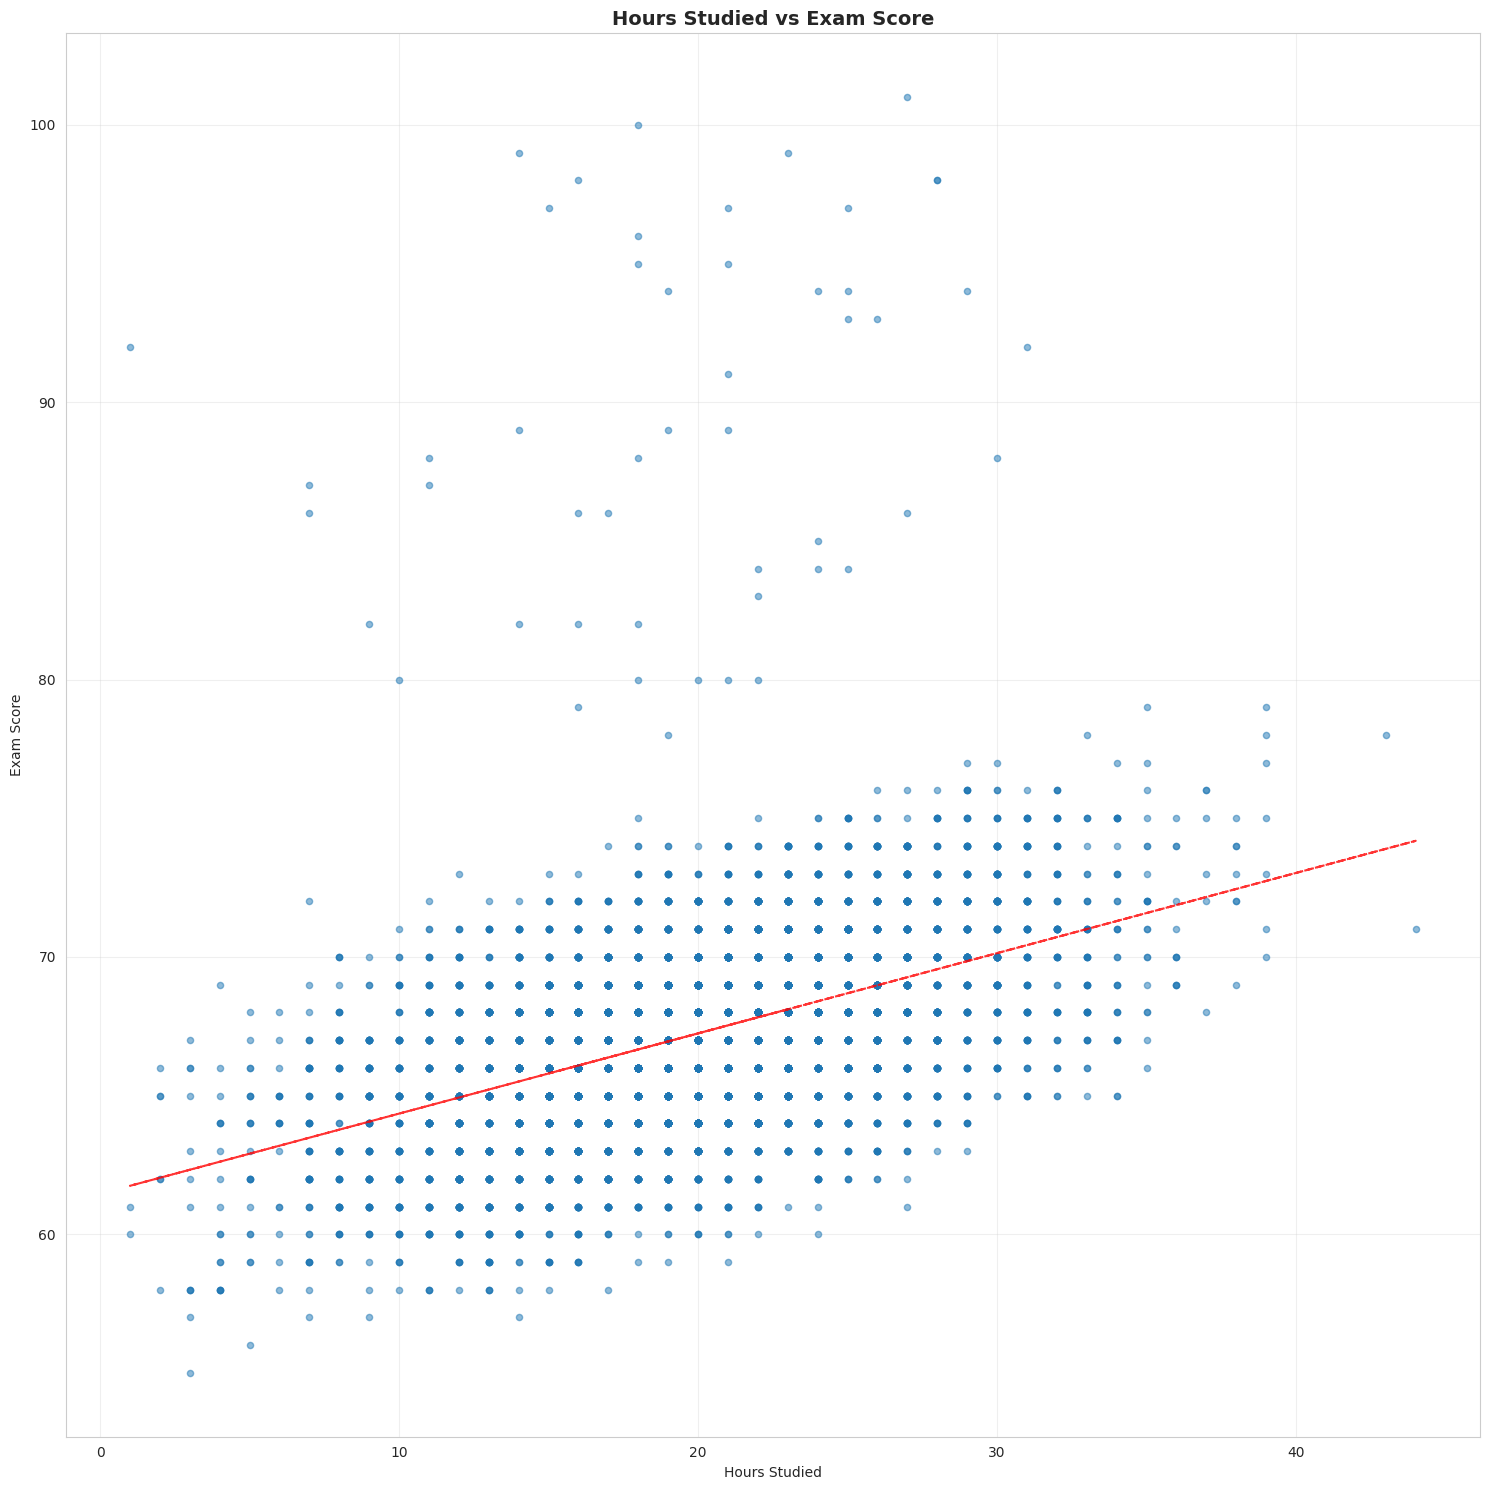

<Figure size 1000x800 with 0 Axes>

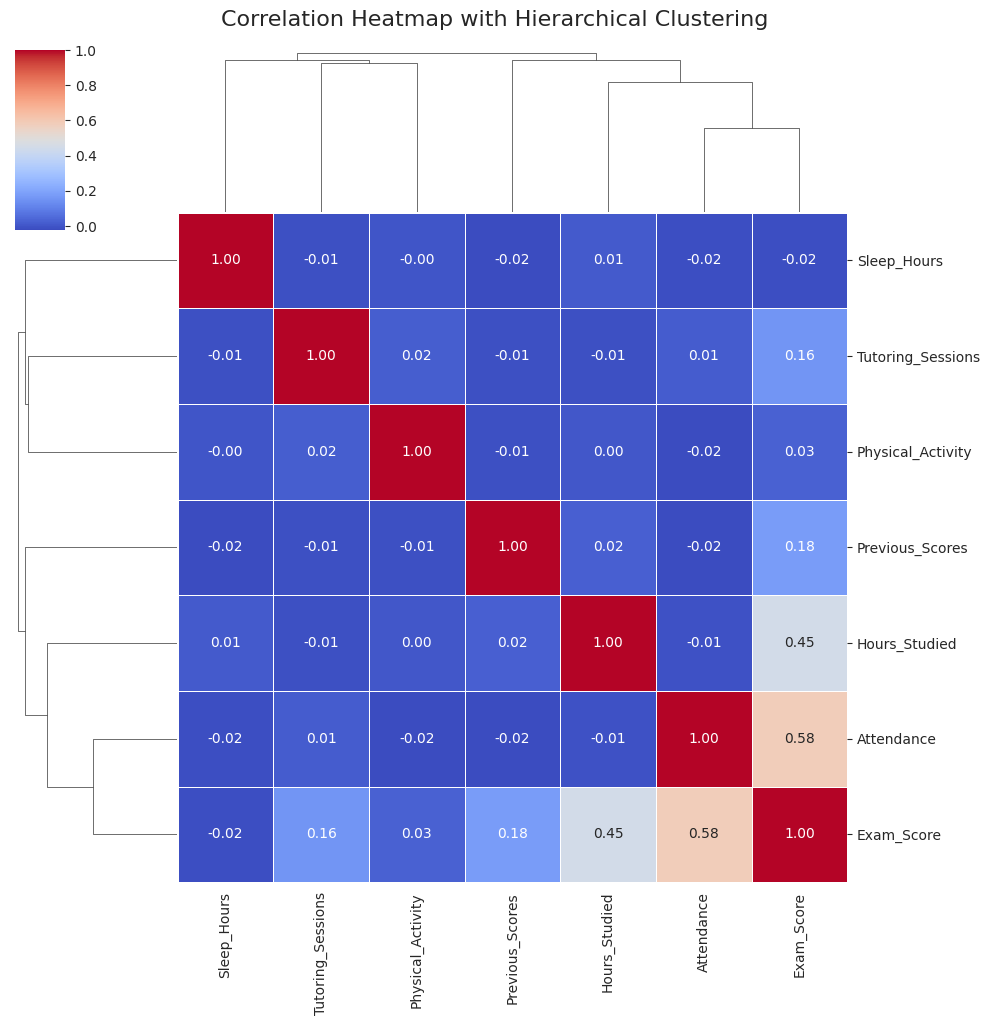


Shape of DataFrame after One-Hot Encoding: (6607, 42)
First 5 rows of the encoded DataFrame:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Pass_Exam,Parental_Involvement_High,Parental_Involvement_Low,...,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Female,Gender_Male
0,23,84,7,73,0,3,67,1,False,True,...,True,False,False,True,False,False,False,True,False,True
1,19,64,8,59,2,4,61,0,False,True,...,True,False,True,False,False,False,True,False,True,False
2,24,98,7,91,2,4,74,1,False,False,...,True,False,False,False,True,False,False,True,False,True
3,29,89,8,98,1,4,71,1,False,True,...,True,False,False,True,False,False,True,False,False,True
4,19,92,6,65,3,4,70,1,False,False,...,True,False,True,False,False,False,False,True,True,False



Unified Numerical DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 42 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6607 non-null   int64
 1   Attendance                             6607 non-null   int64
 2   Sleep_Hours                            6607 non-null   int64
 3   Previous_Scores                        6607 non-null   int64
 4   Tutoring_Sessions                      6607 non-null   int64
 5   Physical_Activity                      6607 non-null   int64
 6   Exam_Score                             6607 non-null   int64
 7   Pass_Exam                              6607 non-null   int64
 8   Parental_Involvement_High              6607 non-null   bool 
 9   Parental_Involvement_Low               6607 non-null   bool 
 10  Parental_Involvement_Medium            6607 non-null   bool 


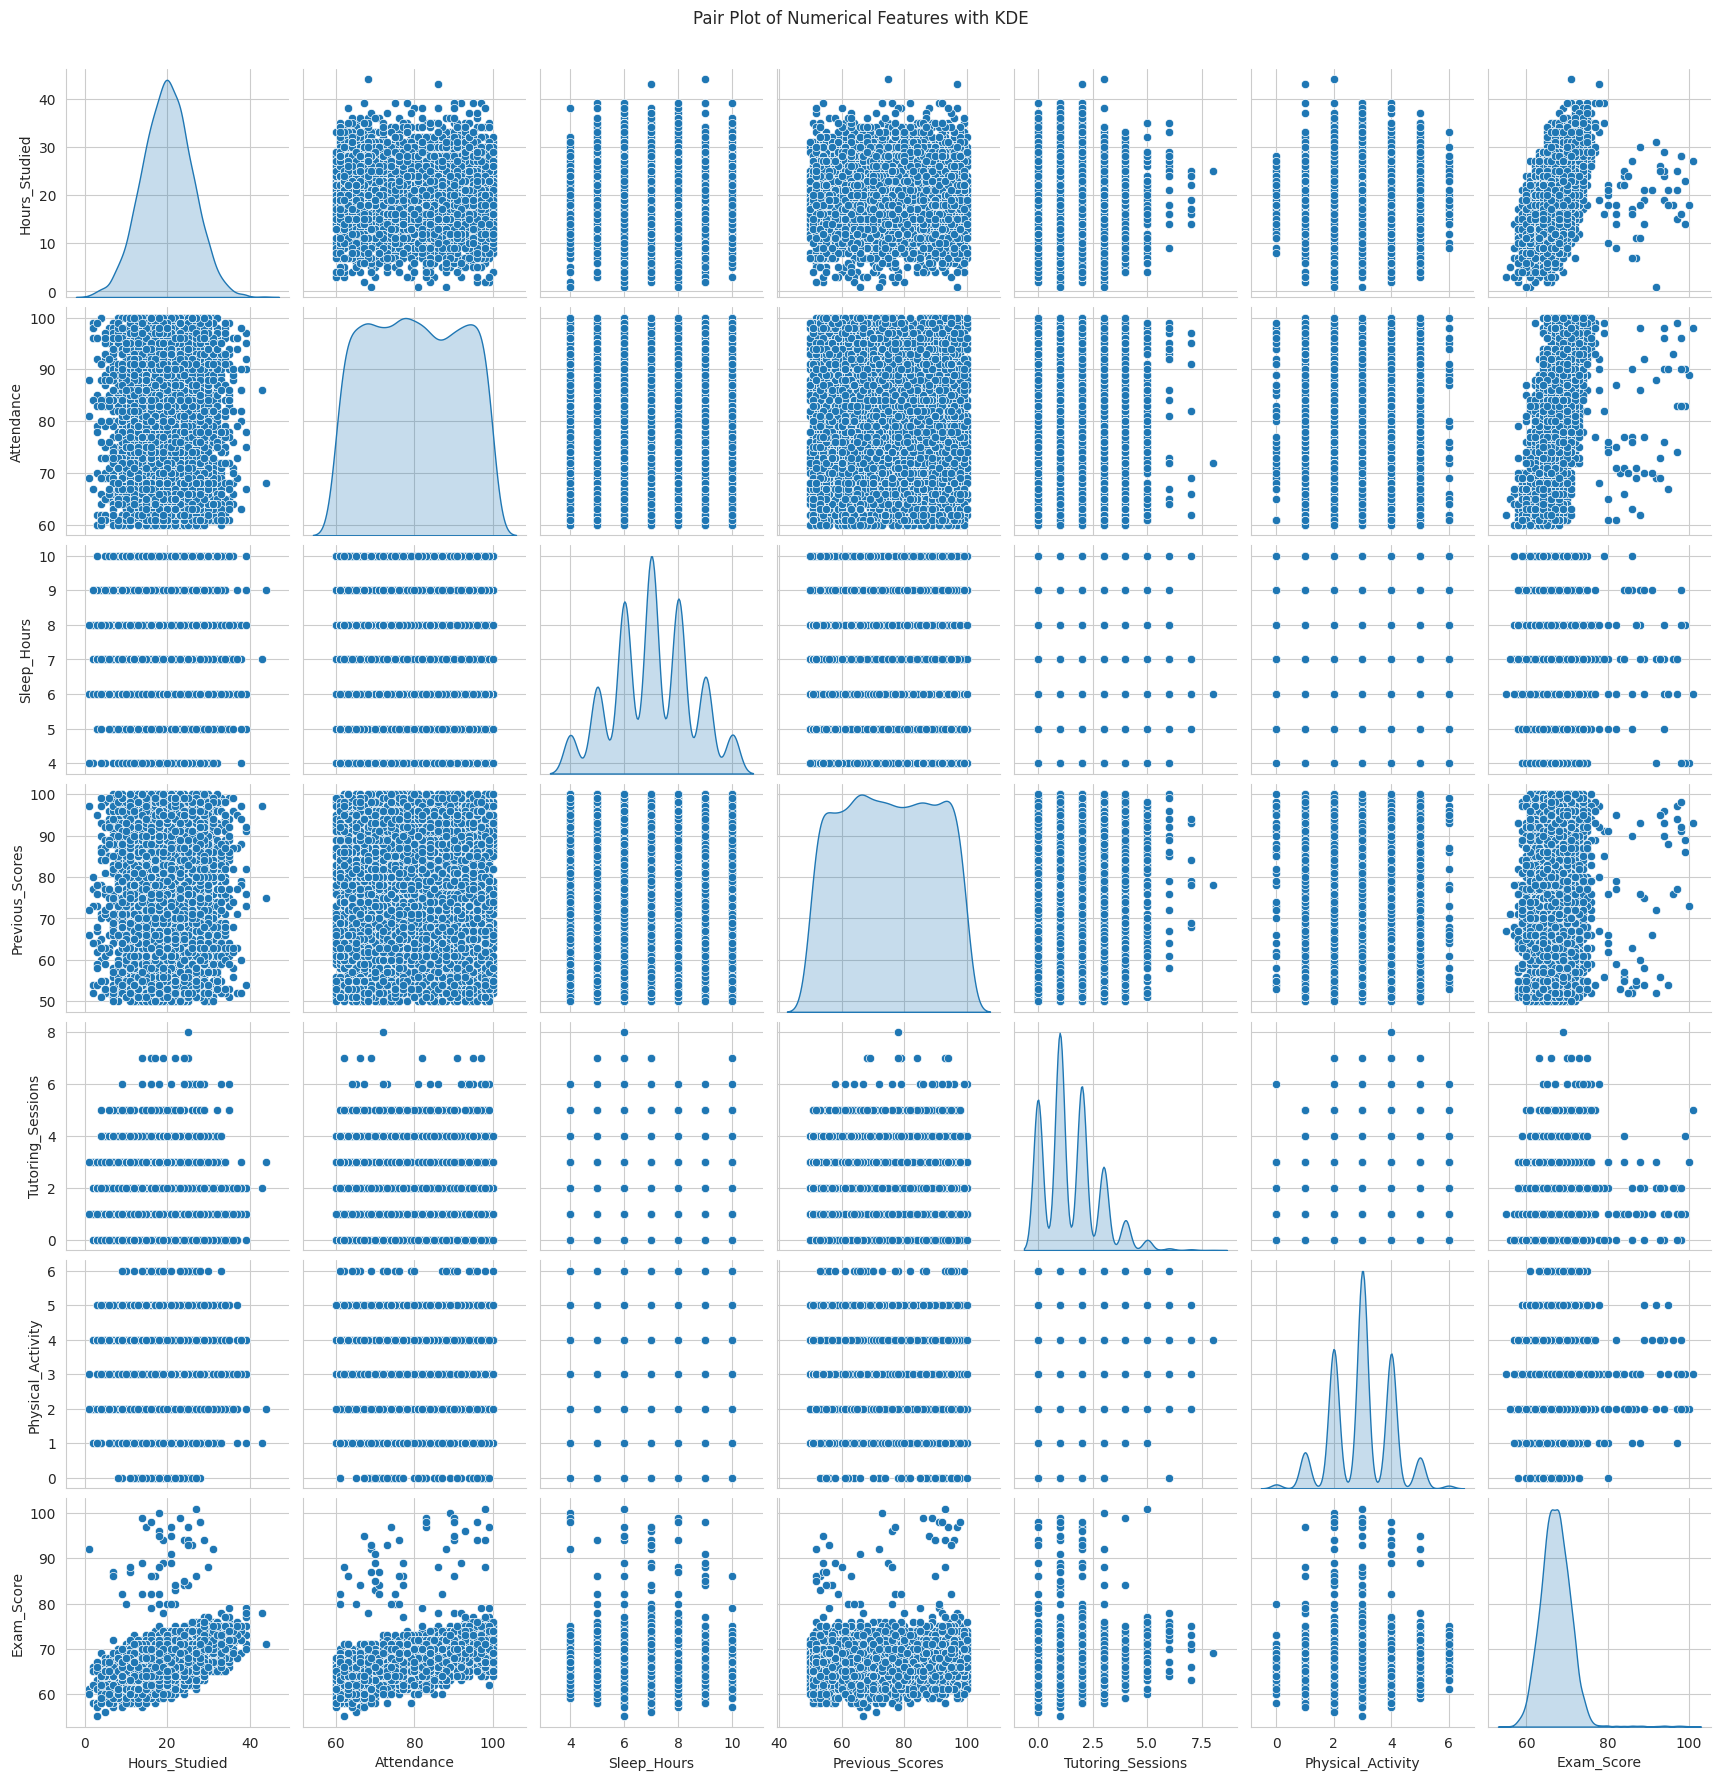

<Figure size 2000x1800 with 0 Axes>

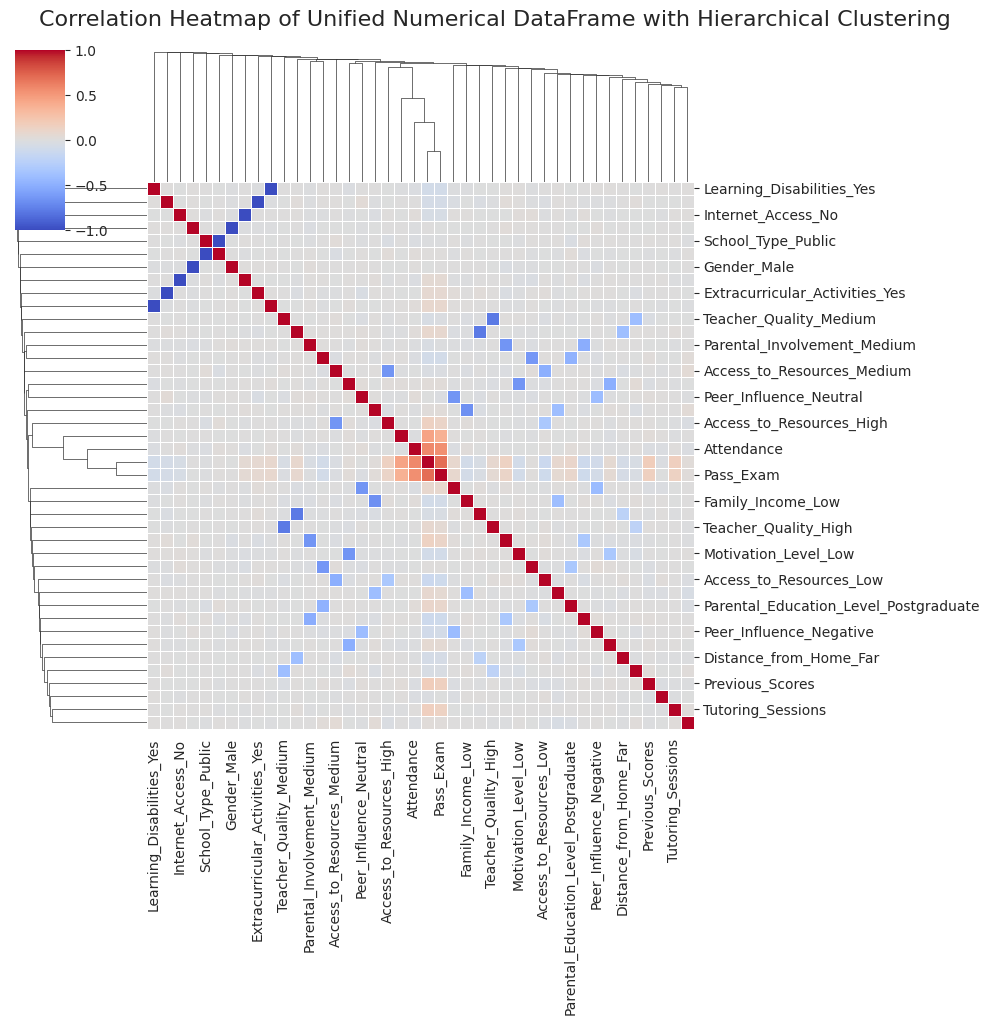

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def create_visualiuzation(df):
    fig, axes = plt.subplots(1, 1, figsize=(15, 15))
    axes.scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.5, s=20)
    z = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)
    p = np.poly1d(z)
    axes.plot(df['Hours_Studied'], p(df['Hours_Studied']), "r--", alpha=0.8)
    axes.set_title('Hours Studied vs Exam Score', fontsize=14, fontweight='bold')
    axes.set_xlabel('Hours Studied')
    axes.set_ylabel('Exam Score')
    axes.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


create_visualiuzation(df)
numerical_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
numerical_df = df[numerical_cols].copy()
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.clustermap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.suptitle('Correlation Heatmap with Hierarchical Clustering', y=1.02, fontsize=16)
plt.show()

categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
print("\nShape of DataFrame after One-Hot Encoding:", df_encoded.shape)
print("First 5 rows of the encoded DataFrame:")
display(df_encoded.head())
original_numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
unified_numerical_df = df_encoded
print("\nUnified Numerical DataFrame Info:")
unified_numerical_df.info()

import seaborn as sns
import matplotlib.pyplot as plt

print("\nGenerating Pair Plot for Numerical Features with KDE...")
sns.pairplot(numerical_df, diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features with KDE', y=1.02)
plt.show()

correlation_matrix_unified = unified_numerical_df.corr()
plt.figure(figsize=(20, 18))
sns.clustermap(correlation_matrix_unified, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.suptitle('Correlation Heatmap of Unified Numerical DataFrame with Hierarchical Clustering', y=1.02, fontsize=16)
plt.show()

# QUESTION 3 - PART 1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.theta = None
    def sigmoid(self, z):
        """Sigmoid activation function."""
        return 1 / (1 + np.exp(-z))

    def compute_cost(self, X, y):
      m = X.shape[0]
      h = self.sigmoid(np.dot(X, self.theta))
      h = np.clip(h, 1e-15, 1 - 1e-15)

      y_np = y.to_numpy() if isinstance(y, pd.Series) else y
      y_np = y_np.reshape(m, 1)

      cost = -(1 / m) * np.sum(y_np * np.log(h) + (1 - y_np) * np.log(1 - h))
      return cost




    def fit(self, X, y):
        """Train the logistic regression model using gradient descent."""
        m, n = X.shape
        self.theta = np.zeros((n, 1))

        y_np = y.to_numpy() if isinstance(y, pd.Series) else y
        y_reshaped = y_np.reshape(m, 1)

        for i in range(self.num_iterations):
            h = self.sigmoid(np.dot(X, self.theta))

            gradient = (1 / m) * np.dot(X.T, (h - y_reshaped))

            self.theta -= self.learning_rate * gradient

            if i % 100 == 0:
                cost = self.compute_cost(X, y)
                print(f"Iteration {i} | Cost: {cost:.4f}")

    def predict(self, X, threshold=0.5):
        """Predict binary class labels."""
        probabilities = self.sigmoid(np.dot(X, self.theta))
        return (probabilities >= threshold).astype(int)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

X = unified_numerical_df.drop(columns=['Exam_Score', 'Pass_Exam'])
y = unified_numerical_df['Pass_Exam']

X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_scaled = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

model = LogisticRegression(learning_rate=0.01, num_iterations=2000)
print("\nTraining the Logistic Regression model.")
model.fit(X_train_scaled, y_train)
print("\nMaking predictions on the test set.")
y_pred = model.predict(X_test_scaled).ravel()
accuracy = np.mean(y_pred.flatten() == y_test) * 100
print(f"Model Accuracy: {accuracy:.2f}%")

print("\nModel Evaluation:")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))



Training the Logistic Regression model...
Iteration 0 | Cost: 0.6915
Iteration 100 | Cost: 0.5617
Iteration 200 | Cost: 0.4819
Iteration 300 | Cost: 0.4286
Iteration 400 | Cost: 0.3905
Iteration 500 | Cost: 0.3618
Iteration 600 | Cost: 0.3392
Iteration 700 | Cost: 0.3210
Iteration 800 | Cost: 0.3058
Iteration 900 | Cost: 0.2930
Iteration 1000 | Cost: 0.2820
Iteration 1100 | Cost: 0.2724
Iteration 1200 | Cost: 0.2639
Iteration 1300 | Cost: 0.2564
Iteration 1400 | Cost: 0.2497
Iteration 1500 | Cost: 0.2436
Iteration 1600 | Cost: 0.2380
Iteration 1700 | Cost: 0.2330
Iteration 1800 | Cost: 0.2283
Iteration 1900 | Cost: 0.2240

Making predictions on the test set...
Model Accuracy: 96.82%

Model Evaluation:
Confusion Matrix:
[[407  19]
 [ 23 873]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       426
           1       0.98      0.97      0.98       896

    accuracy                           0.97      1322
   ma

In [ ]:
class LogisticRegression_GD_Variants:
    def __init__(self, learning_rate=0.01, num_iterations=1000, batch_size=None):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.batch_size = batch_size
        self.theta = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_cost(self, X, y):
        m = X.shape[0]
        h = self.sigmoid(np.dot(X, self.theta))
        # Ensure y is a NumPy array for element-wise operations
        y_np = y.to_numpy() if isinstance(y, pd.Series) else y
        # Add small value to avoid log(0) and log(1-0) issues
        h = np.clip(h, 1e-10, 1 - 1e-10)
        cost = -(1 / m) * np.sum(y_np * np.log(h) + (1 - y_np) * np.log(1 - h))
        return cost

    def fit(self, X, y, method="batch"):
        m, n = X.shape
        self.theta = np.zeros((n, 1))

        y_np = y.to_numpy() if isinstance(y, pd.Series) else y
        y_reshaped = y_np.reshape(m, 1)

        for i in range(self.num_iterations):
            if method == "batch":
                h = self.sigmoid(np.dot(X, self.theta))
                gradient = (1 / m) * np.dot(X.T, (h - y_reshaped))
                self.theta -= self.learning_rate * gradient

            elif method == "mini-batch":
                indices = np.random.permutation(m)
                X_shuffled = X[indices]
                y_shuffled = y_reshaped[indices] # Use y_reshaped here

                for start_idx in range(0, m, self.batch_size):
                    end_idx = min(start_idx + self.batch_size, m)
                    X_batch = X_shuffled[start_idx:end_idx]
                    y_batch = y_shuffled[start_idx:end_idx]
                    h = self.sigmoid(np.dot(X_batch, self.theta))
                    gradient = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (h - y_batch))
                    self.theta -= self.learning_rate * gradient


            elif method == "stochastic":
                indices = np.random.permutation(m)
                X_shuffled = X[indices]
                y_shuffled = y_reshaped[indices]
                for j in range(m):
                    X_j = X_shuffled[j, :].reshape(1, -1)
                    y_j = y_shuffled[j].reshape(1, 1)
                    h = self.sigmoid(np.dot(X_j, self.theta))
                    grad_j = np.dot(X_j.T, (h - y_j))
                    self.theta -= self.learning_rate * grad_j
            else:
                raise ValueError("Invalid method. Choose 'batch', 'stochastic', or 'mini-batch'.")

            # Print cost every 100 iterations
            if i % 100 == 0:
                cost = self.compute_cost(X, y_reshaped) # Pass y_reshaped to compute_cost
                print(f"Iteration {i} | Cost: {cost:.4f} | Method: {method}")

    def predict(self, X, threshold=0.5):
        probabilities = self.sigmoid(np.dot(X, self.theta))
        return (probabilities >= threshold).astype(int)


for method in ["stochastic", "mini-batch","batch"]:
    print(f"\nTraining with {method.capitalize()} Gradient Descent")
    batch_size = 32 if method == "mini-batch" else None
    lr_variant = LogisticRegression_GD_Variants(learning_rate=0.01, num_iterations=1000, batch_size=batch_size)

    lr_variant.fit(X_train_scaled, y_train, method=method)
    predictions = lr_variant.predict(X_test_scaled)
    accuracy = np.mean(predictions.flatten() == y_test) * 100
    print(f"{method.capitalize()} GD Accuracy: {accuracy:.2f}%")


Training with Batch Gradient Descent...
Iteration 0 | Cost: 0.6915 | Method: batch
Iteration 100 | Cost: 0.5617 | Method: batch
Iteration 200 | Cost: 0.4819 | Method: batch
Iteration 300 | Cost: 0.4286 | Method: batch
Iteration 400 | Cost: 0.3905 | Method: batch
Iteration 500 | Cost: 0.3618 | Method: batch
Iteration 600 | Cost: 0.3392 | Method: batch
Iteration 700 | Cost: 0.3210 | Method: batch
Iteration 800 | Cost: 0.3058 | Method: batch
Iteration 900 | Cost: 0.2930 | Method: batch
Batch GD Accuracy: 96.52%

Training with Stochastic Gradient Descent...
Iteration 0 | Cost: 0.1614 | Method: stochastic
Iteration 100 | Cost: 0.0806 | Method: stochastic
Iteration 200 | Cost: 0.0801 | Method: stochastic
Iteration 300 | Cost: 0.0803 | Method: stochastic
Iteration 400 | Cost: 0.0804 | Method: stochastic
Iteration 500 | Cost: 0.0798 | Method: stochastic
Iteration 600 | Cost: 0.0798 | Method: stochastic
Iteration 700 | Cost: 0.0800 | Method: stochastic
Iteration 800 | Cost: 0.0800 | Method: st

## 3.2 Explain Convergance properties with respect to your cost function


Batch Gradient Descent
- computes the gradient of the cost function using the entire dataset at each iteration
- the full dataset is uysed, which makes convergance smooth and stable

Stochastic Gradient Descent
- updates weights for each individual data point
-faster inital convergance


Mini Batch Gradient Descent
- updates weights using a small batch of data at each iteration
- cost function decreases steadily
- converges smoothly when batch size is large
- cost is low when the batch size is small



Batch Gradient Descent
Over 900 iterations, the cost went from .6915 ->.2930. This is a very smooth and stable convergance.

Stochastic Gradient Descent
The cost goes from .1609 -> .0800, and then it plateaus.

Mini batch Gradient Descent:
0.5058 -> 0.0836 smooths pretty fast


One unexpected behavior was that the printed ‘cost at iteration 0’ differed substantially across GD variants. This likely occurred because the logging cost was computed on the current sample/mini-batch rather than the full training set.


#TASK 4 - Optimization Techniques and Advanced Comparison


--- Hyperparameter Tuning for SGD ---
Iteration    0 | Cost: 0.6930 | Optimizer: sgd
Iteration  100 | Cost: 0.6766 | Optimizer: sgd
Iteration  200 | Cost: 0.6612 | Optimizer: sgd
Iteration  300 | Cost: 0.6465 | Optimizer: sgd
Iteration  400 | Cost: 0.6326 | Optimizer: sgd
Iteration  500 | Cost: 0.6194 | Optimizer: sgd
Iteration  600 | Cost: 0.6069 | Optimizer: sgd
Iteration  700 | Cost: 0.5950 | Optimizer: sgd
Iteration  800 | Cost: 0.5837 | Optimizer: sgd
Iteration  900 | Cost: 0.5730 | Optimizer: sgd
Iteration    0 | Cost: 0.6915 | Optimizer: sgd
Iteration  100 | Cost: 0.5617 | Optimizer: sgd
Iteration  200 | Cost: 0.4819 | Optimizer: sgd
Iteration  300 | Cost: 0.4286 | Optimizer: sgd
Iteration  400 | Cost: 0.3905 | Optimizer: sgd
Iteration  500 | Cost: 0.3618 | Optimizer: sgd
Iteration  600 | Cost: 0.3392 | Optimizer: sgd
Iteration  700 | Cost: 0.3210 | Optimizer: sgd
Iteration  800 | Cost: 0.3058 | Optimizer: sgd
Iteration  900 | Cost: 0.2930 | Optimizer: sgd
Iteration    0 | Cost

<Figure size 1200x600 with 0 Axes>

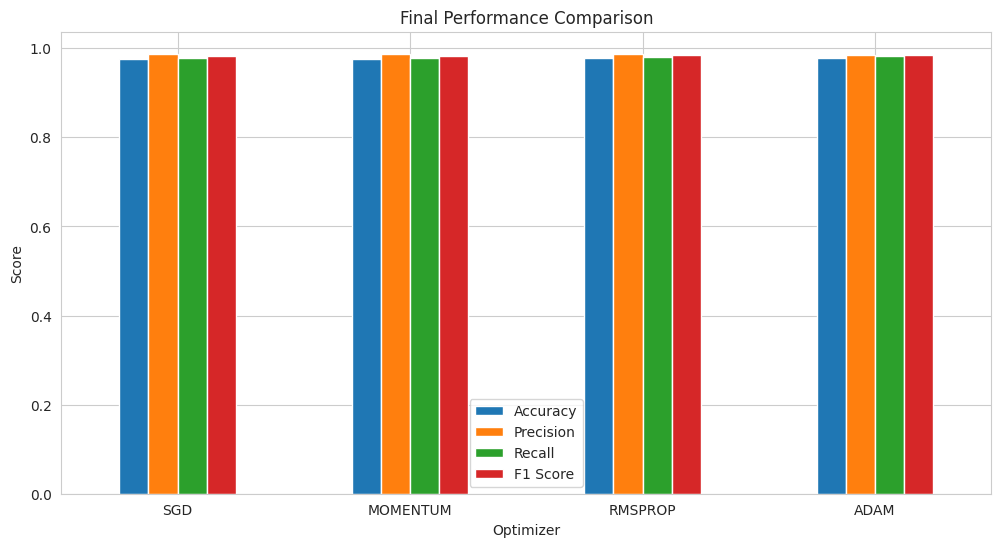

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


class LogisticRegressionOptimized:
    def __init__(self,
                 learning_rate=0.01,
                 num_iterations=1000,
                 optimizer="sgd",
                 beta=0.9,
                 beta2=0.999,
                 epsilon=1e-8):

        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.optimizer = optimizer
        self.beta = beta
        self.beta2 = beta2
        self.epsilon = epsilon
        self.theta = None
        self.velocity = None
        self.squared_grad = None
        self.m_t = None
        self.v_t = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_cost(self, X, y):
        m = X.shape[0]
        h = self.sigmoid(np.dot(X, self.theta))
        y_np = y.to_numpy() if isinstance(y, pd.Series) else y
        h = np.clip(h, 1e-10, 1 - 1e-10)
        cost = -(1 / m) * np.sum(
            y_np * np.log(h) + (1 - y_np) * np.log(1 - h)
        )
        return cost

    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.velocity = np.zeros((n, 1))
        self.squared_grad = np.zeros((n, 1))
        self.m_t = np.zeros((n, 1))
        self.v_t = np.zeros((n, 1))

        y_np = y.to_numpy() if isinstance(y, pd.Series) else y
        y = y_np.reshape(m, 1)

        for i in range(self.num_iterations):
            h = self.sigmoid(np.dot(X, self.theta))
            gradient = (1 / m) * np.dot(X.T, (h - y))

            if self.optimizer == "momentum":
                self.velocity = self.beta * self.velocity + (1 - self.beta) * gradient
                self.theta -= self.learning_rate * self.velocity

            elif self.optimizer == "rmsprop":
                self.squared_grad = self.beta * self.squared_grad + (1 - self.beta) * (gradient ** 2)
                self.theta -= self.learning_rate * gradient / (np.sqrt(self.squared_grad) + self.epsilon)

            elif self.optimizer == "adam":
                self.m_t = self.beta * self.m_t + (1 - self.beta) * gradient
                self.v_t = self.beta2 * self.v_t + (1 - self.beta2) * (gradient ** 2)

                m_t_corrected = self.m_t / (1 - self.beta ** (i + 1))
                v_t_corrected = self.v_t / (1 - self.beta2 ** (i + 1))

                self.theta -= self.learning_rate * m_t_corrected / (np.sqrt(v_t_corrected) + self.epsilon)

            else:
                self.theta -= self.learning_rate * gradient

            if i % 100 == 0:
                cost = self.compute_cost(X, y)
                print(f"Iteration {i:4d} | Cost: {cost:.4f} | Optimizer: {self.optimizer}")

    def predict(self, X, threshold=0.5):
        probabilities = self.sigmoid(np.dot(X, self.theta))
        return (probabilities >= threshold).astype(int)

learning_rates = [0.001, 0.01, 0.1]
betas = [0.8, 0.9]
num_iterations = 1000

optimizer_best = {}





for optimizer in ["sgd", "momentum", "rmsprop", "adam"]:
    print(f"\n--- Hyperparameter Tuning for {optimizer.upper()} ---")
    best_accuracy = 0.0
    best_params = {}

    if optimizer == "sgd":
        for lr in learning_rates:
            model = LogisticRegressionOptimized(
                learning_rate=lr,
                num_iterations=num_iterations,
                optimizer=optimizer
            )
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
            acc = accuracy_score(y_test, preds)
            if acc > best_accuracy:
                best_accuracy = acc
                best_params = {"learning_rate": lr}
    else:
        for lr in learning_rates:
            for b in betas:
                model = LogisticRegressionOptimized(
                    learning_rate=lr,
                    num_iterations=num_iterations,
                    optimizer=optimizer,
                    beta=b
                )
                model.fit(X_train_scaled, y_train)
                preds = model.predict(X_test_scaled)
                acc = accuracy_score(y_test, preds)
                if acc > best_accuracy:
                    best_accuracy = acc
                    best_params = {"learning_rate": lr, "beta": b}

    optimizer_best[optimizer] = {
        "best_accuracy": best_accuracy,
        "best_params": best_params
    }
    print(f"Best Acc for {optimizer.upper()}: {best_accuracy:.4f} with params {best_params}")

results = []
for optimizer in ["sgd", "momentum", "rmsprop", "adam"]:
    print(f"\n--- Final Training with Best Hyperparams for {optimizer.upper()} ---")

    best_params = optimizer_best[optimizer]["best_params"]
    if optimizer == "sgd":
        model = LogisticRegressionOptimized(
            learning_rate=best_params["learning_rate"],
            num_iterations=1000,
            optimizer=optimizer
        )
    else:
        model = LogisticRegressionOptimized(
            learning_rate=best_params["learning_rate"],
            num_iterations=1000,
            optimizer=optimizer,
            beta=best_params["beta"] if "beta" in best_params else 0.9
        )
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "Optimizer": optimizer.upper(),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy: {accuracy:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1 Score: {f1:.2f}")

results_df = pd.DataFrame(results)
print("\n--- Final Comparison of Optimizers ---")
print(results_df)

plt.figure(figsize=(12, 6))
results_df.plot(x="Optimizer", kind="bar", figsize=(12, 6), title="Final Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.show()

# 4.1 NOTES AND COMMENTS

Momentum matched vanilla SGD almost exactly in accuracy/F1, suggesting the problem was already well after scaling/encoding and SGD with a good learning rate did not suffer from strong oscillations where momentum typically helps.

## Task 4 question 1 comparison

To satisfy the requirement of comparing optimization techniques against the vanilla stochastic gradient descent (SGD) implementation from Task 3, I used the Task 3 SGD results as my baseline (Cost ≈ 0.0800 by ~900 iterations, Accuracy = 97.73%). I then implemented three optimization algorithms—Momentum, RMSProp, and Adam—and tuned their hyperparameters over learning rates
{0.001,0.01,0.1}
{0.001,0.01,0.1} and
β ∈{0.8,0.9}
β∈{0.8,0.9} (where applicable)

Adam acheived the fastest early loss drop with the lowest cost, while also matching the overall best performance.


## Task 4 Question 2
To evaluate comparison of performance, I computed precision,recall, accuracy, and f1 score. See graph above for bar plot of comparisons.

## Task 4 Question 3

Learning rate dominated performance.  Too small slowed convergence and too large risked overshooting. RMSProp preferred a smaller learning rate (0.01) because adaptive scaling already amplifies effective step sizes, while SGD/Momentum/Adam performed best at 0.1 under my search

## Task 4 , question 4

SGD and Momentum are the most suitable for the largest datasets, and both have a moderate convergance speed. RMS and Adam are moderatly suited for large datasets, and both have a fast convergance speed.
SGD is the best for large datasets. Monteum is best for slow gradient problems. RMS is best for data evolvement ( aka, if the data is distributing or the gradients are consistently changing/ the ground truth is moving). Adam is best for general optimization.

# EXTRA CITATIONS

https://library.virginia.edu/data/articles/addressing-multicollinearity?

https://link.springer.com/article/10.1007/s11135-006-9018-6?

https://www.statsmodels.org/dev/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html?utm_source=chatgpt.com

